In [14]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns

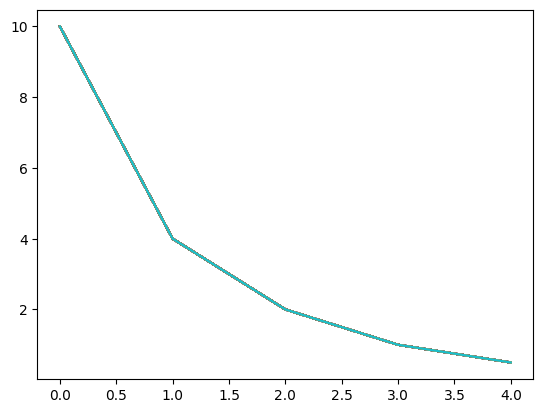

In [15]:
N_p = 100 # patients
N_t = 5 # time points (number of)
sc = 12 # scaling factor

y0 = np.zeros((N_p, N_t)) + np.array([10, 4, 2, 1, .5])

plt.plot(y0.T)
plt.show()

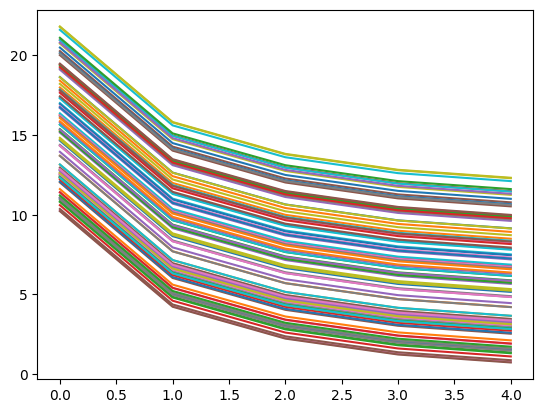

In [16]:
y_add = y0 + np.random.rand(N_p)[:, None] * sc

plt.plot(y_add.T)
plt.show()

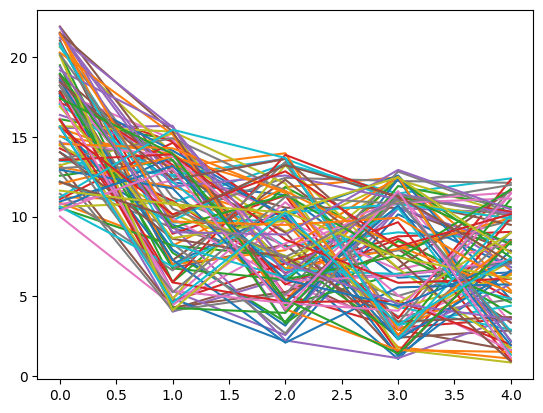

In [17]:
y_mult = y0 + np.random.rand(N_p, N_t) * sc

plt.plot(y_mult.T)
plt.show()

In [18]:
df_add = pd.DataFrame(data=y_add, columns=[f'T{i}' for i in range(N_t)])
df_add['Patient'] = np.arange(N_p) + 100
df_add = pd.melt(df_add, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_add, groups='Patient').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   500       Method:               REML     
No. Groups:         100       Scale:                0.0000   
Min. group size:    5         Log-Likelihood:       3646.9726
Max. group size:    5         Converged:            Yes      
Mean group size:    5.0                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   15.380     0.148      103.626 0.000 15.089 15.671
Week[T.T1]  -6.000     0.000 -3470954.339 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -4627939.119 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -5206431.509 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -5495677.704 0.000 -9.500 -9.500
Patient Var  2.203 12807.167                                 
=============================================================

"""

In [19]:
model.fe_params.to_numpy().shape

(5,)

In [20]:
np.empty(5).shape

(5,)

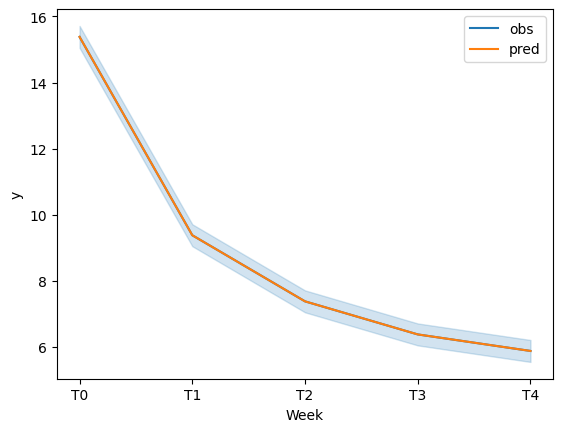

In [21]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_add, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [22]:
kill = np.random.randint(low=0, high=50, size=20)
df_add_kill = df_add.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_add_kill, groups='Patient').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   485       Method:               REML     
No. Groups:         100       Scale:                0.0000   
Min. group size:    4         Log-Likelihood:       3494.2874
Max. group size:    5         Converged:            Yes      
Mean group size:    4.8                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   15.380     0.151      102.043 0.000 15.085 15.675
Week[T.T1]  -6.000     0.000 -3255212.743 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -4340283.657 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -4882819.114 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -5154086.843 0.000 -9.500 -9.500
Patient Var  2.272 13306.172                                 
=============================================================

"""

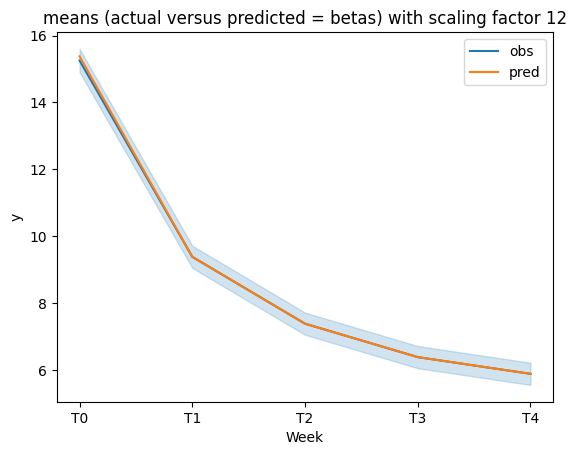

In [23]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()

# bi + b0 = mean(timepoint i) for i != 0
b[1:] += b[0] 
sem[1:] += sem[0]

sns.lineplot(data=df_add_kill, x='Week', y='y', errorbar='se', label = 'obs')
plt.plot(b,label = 'pred')

plt.legend()
plt.title(f"means (actual versus predicted = betas) with scaling factor {sc}")
plt.show()

## Multiplicative differences

In [30]:
df_mult = pd.DataFrame(data=y_mult, columns=[f'T{i}' for i in range(N_t)])
df_mult['Patient'] = np.arange(N_p) + 100
df_mult = pd.melt(df_mult, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

# log transform it
#df_mult['y'] = np.log(df_mult['y'])

model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient').fit()

model.summary()

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
========================================================
Model:            MixedLM Dependent Variable: y         
No. Observations: 500     Method:             REML      
No. Groups:       100     Scale:              12.3608   
Min. group size:  5       Log-Likelihood:     -1336.2344
Max. group size:  5       Converged:          Yes       
Mean group size:  5.0                                   
--------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
--------------------------------------------------------
Intercept   16.194    0.352  46.060 0.000  15.505 16.883
Week[T.T1]  -5.943    0.497 -11.953 0.000  -6.918 -4.969
Week[T.T2]  -7.948    0.497 -15.985 0.000  -8.922 -6.973
Week[T.T3]  -8.885    0.497 -17.870 0.000  -9.859 -7.910
Week[T.T4]  -9.500    0.497 -19.107 0.000 -10.474 -8.525
Patient Var  0.000    0.136                             
========================================================

"""

In [25]:
# catch warnings
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
store_exceptions = []
try:
    with warnings.catch_warnings():
        warnings.filterwarnings('error', category = ConvergenceWarning)
        model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient', re_formula = '~Week').fit()
    a, b = model.fe_params.to_numpy(), True
except Exception as e:
    store_exceptions.append(e)
    print('no')


no


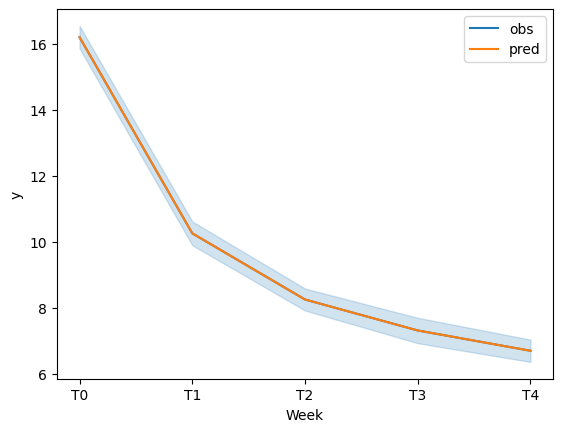

In [26]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [27]:
# same values killed as with the additive model
df_mult_kill = df_mult.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_mult_kill, groups='Patient', re_formula = '~Week').fit()

model.summary()


/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Mixed Linear Model Regression Results
========================================================================
Model:                  MixedLM      Dependent Variable:      y         
No. Observations:       485          Method:                  REML      
No. Groups:             100          Scale:                   8.3663    
Min. group size:        4            Log-Likelihood:          -1290.2826
Max. group size:        5            Converged:               Yes       
Mean group size:        4.8                                             
------------------------------------------------------------------------
                            Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
------------------------------------------------------------------------
Intercept                   16.374    0.372  43.971 0.000  15.644 17.104
Week[T.T1]                  -6.123    0.528 -11.606 0.000  -7.158 -5.089
Week[T.T2]                  -8.128    0.529 -15.376 0.000  -9.164 -7.092
Week[T.T3]                  -9.065    0.504 -17.969 0.000 -10.054 -8.076
Week[T.T4]                  -9.680    0.551 -17.572 0.000 -10.760 -8.600
Patient Var                  3.419                                      
Patient x Week[T.T1] Cov    -4.009                                      
Week[T.T1] Var               9.023                                      
Patient x Week[T.T2] Cov    -5.013                                      
Week[T.T1] x Week[T.T2] Cov  5.760                                      
Week[T.T2] Var               9.127                                      
Patient x Week[T.T3] Cov    -1.841                                      
Week[T.T1] x Week[T.T3] Cov  1.275                                      
Week[T.T2] x Week[T.T3] Cov  1.452                                      
Week[T.T3] Var               6.636                                      
Patient x Week[T.T4] Cov    -5.736                                      
Week[T.T1] x Week[T.T4] Cov  6.116                                      
Week[T.T2] x Week[T.T4] Cov  8.433                                      
Week[T.T3] x Week[T.T4] Cov  5.444                                      
Week[T.T4] Var              11.534                                      
========================================================================

"""

In [28]:
try:
        with warnings.catch_warnings():
            warnings.filterwarnings('error', category = ConvergenceWarning)
            model = smf.mixedlm('y~Week', data = df_mult, groups = 'subj').fit(maxiter = 400)
            print('converged', model.fe_params.to_numpy())
    
except Exception as e:
      print('not converged', model.fe_params.to_numpy())

not converged [16.37409416 -6.12343589 -8.12791344 -9.0652047  -9.68017304]


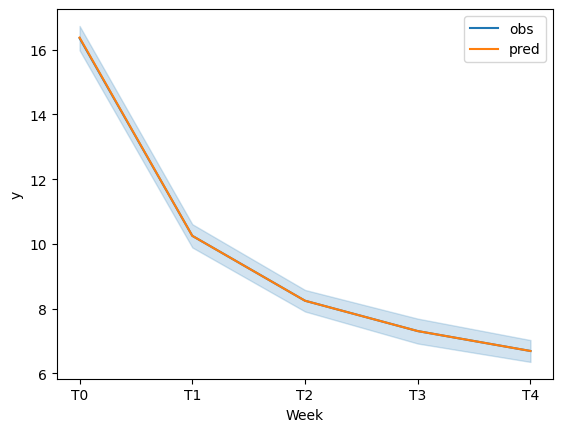

In [29]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult_kill, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)